# Random Forest

## Note

This notebook includes additional images, screenshots, diagrams, and explanatory notes in some sections to support my understanding of the concepts.

 I incorporated these materials as part of my learning process and to create useful study notes for future reference.

  The primary objective was to understand the concepts thoroughly while completing the assignment.


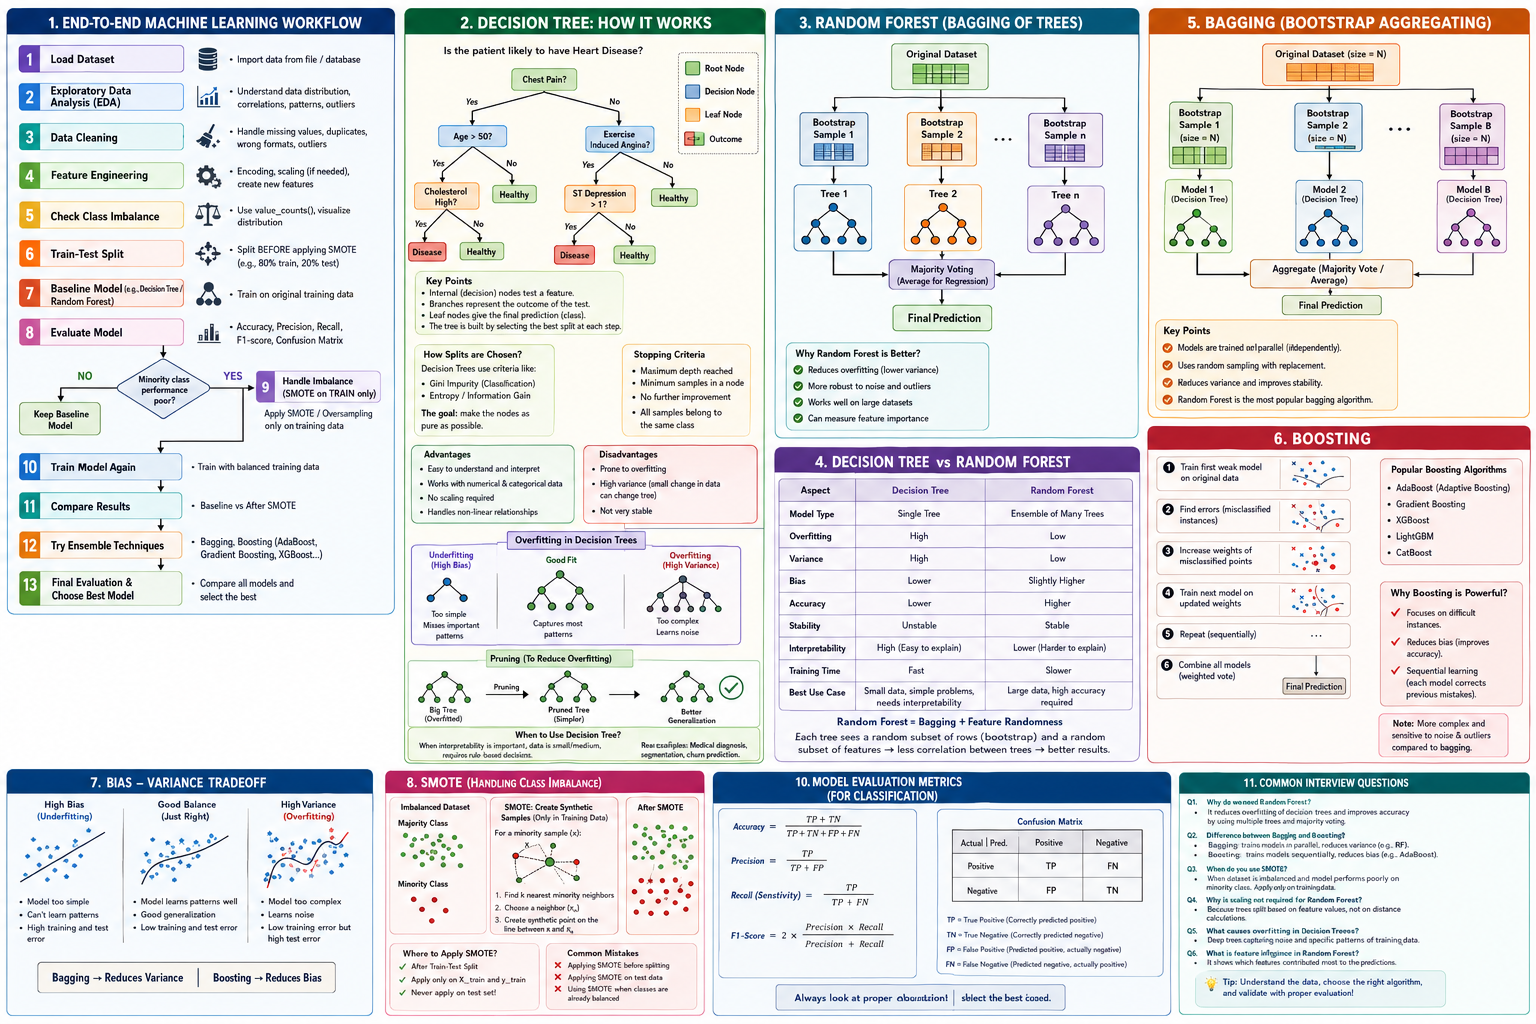

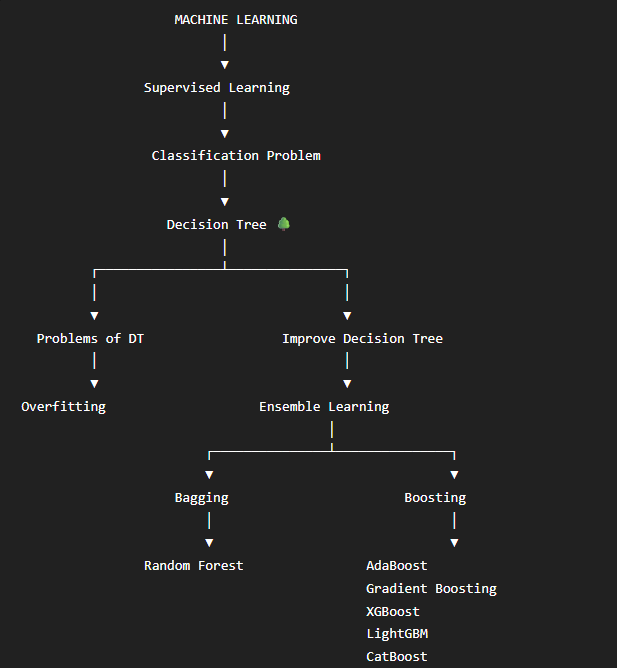

                Glass Dataset
                      │
                      ▼
                     EDA
                      │
                      ▼
             Data Preprocessing
                      │
        (Missing values, duplicates,
         encoding, scaling if needed)
                      │
                      ▼
          Check Class Imbalance
                      │
                      ▼
              Train-Test Split
                      │
                      ▼
        Baseline Random Forest Model
                      │
                      ▼
                 Evaluate Model
                      │
         (Accuracy, Precision, Recall,
          F1 Score, Confusion Matrix)
                      │
                      ▼
      Is minority class performance poor?
               /                  \
             No                    Yes
             │                     │
             ▼                     ▼
      Continue               Apply SMOTE
                              (Train set only)
                                   │
                                   ▼
                         Train Random Forest Again
                                   │
                                   ▼
                             Evaluate Again
                                   │
                                   ▼
                         Compare Both Results
                                   │
                                   ▼
             Now compare Bagging vs Boosting

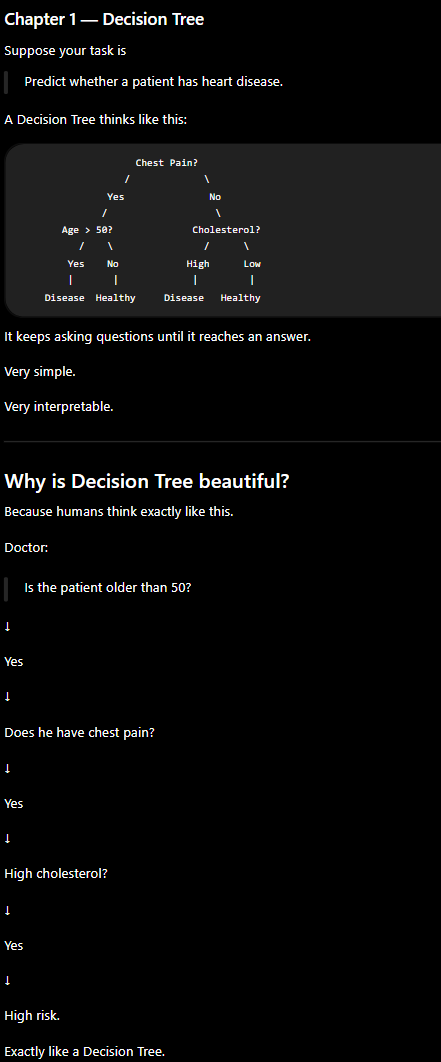

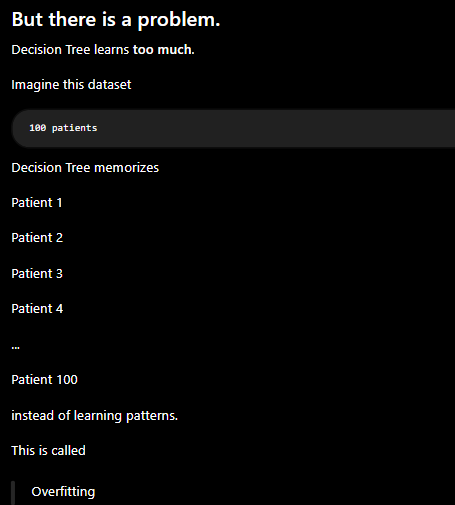

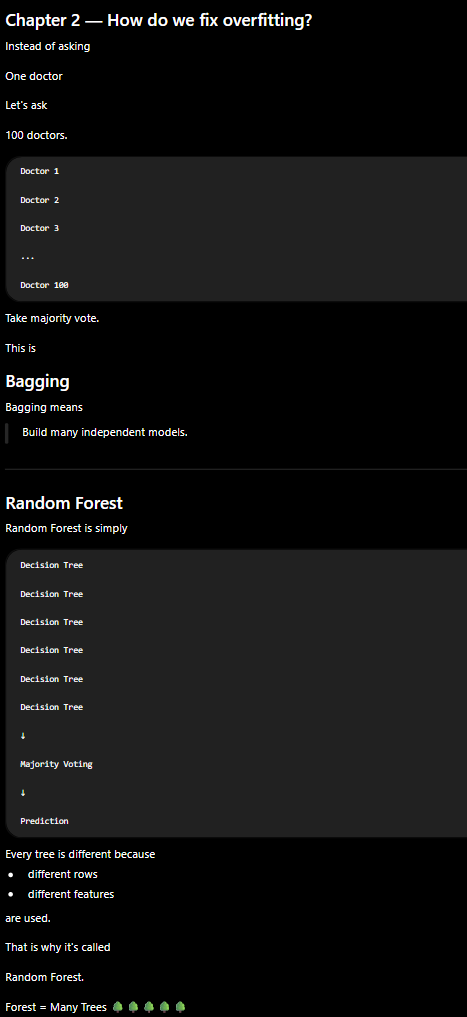

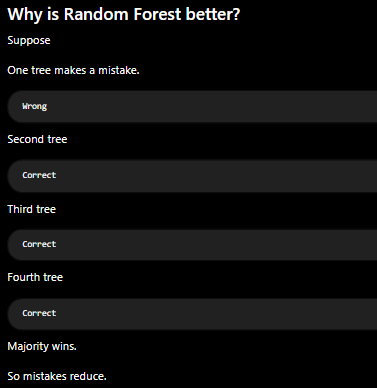

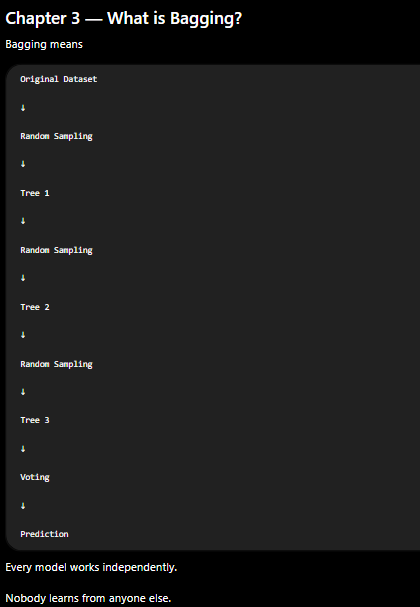

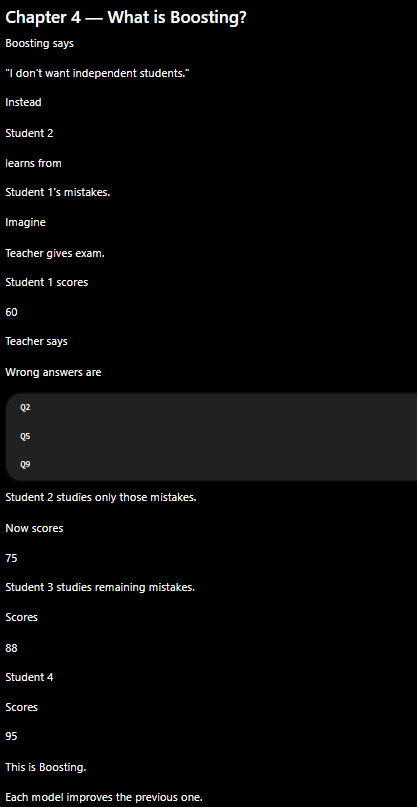

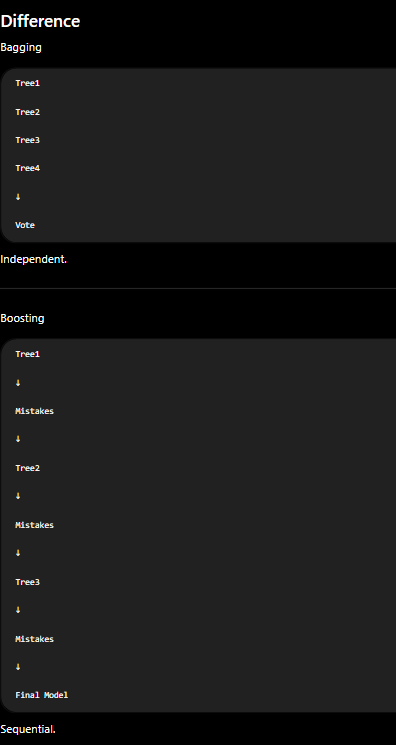

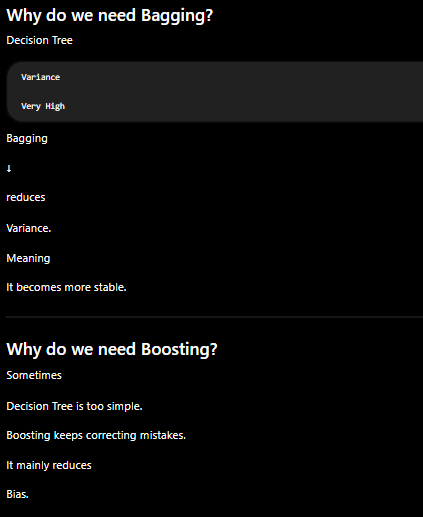

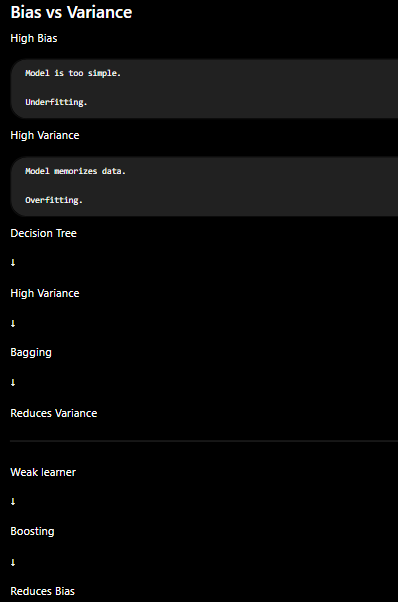

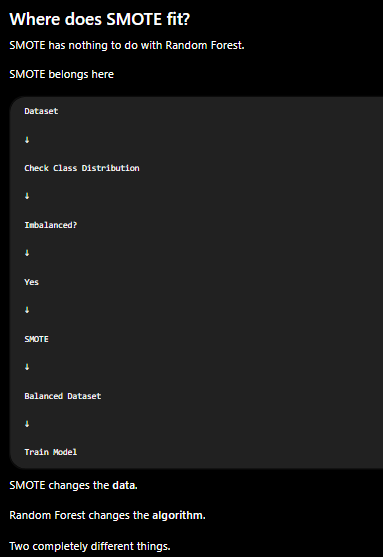

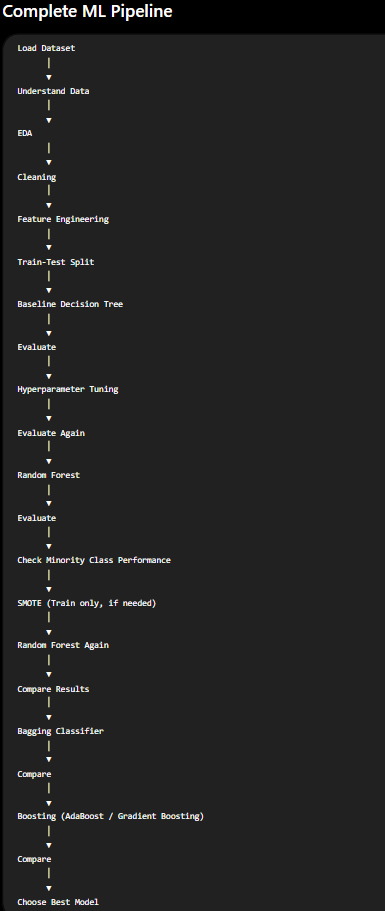

In [26]:
import numpy as np
import pandas as pd

In [27]:
# we have two sheets in excel one is metadata and another has acutal data we need to work on

excel_file = pd.ExcelFile("/content/glass.xlsx")

print(excel_file.sheet_names)

['Description', 'glass']


In [28]:
metadata = pd.read_excel('/content/glass.xlsx',sheet_name='Description')
metadata.head()

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum


In [29]:
df = pd.read_excel('/content/glass.xlsx',sheet_name='glass')


In [30]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [31]:
df.shape

(214, 10)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [33]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [34]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


The Glass dataset contains only numerical features and the target variable is already encoded as integers.

 Therefore, no additional encoding techniques such as One-Hot Encoding or Label Encoding are required.

In [35]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [36]:
df.duplicated().sum() # to check wether there are duplicates rows in the data set or not

np.int64(1)

In [37]:
df[df.duplicated()] # for seeing what the duplicated row is

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [38]:
df = df.drop_duplicates() # we have removed the duplicate rows

In [39]:
df.duplicated().sum() # verifying the duplicate rows

np.int64(0)

In [40]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [41]:
numerical_columns = [
  'RI',
  'Na',
  'Mg',
  'Al',
  'Si',
  'K',
  'Ca',
  'Ba',
  'Fe'
]

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

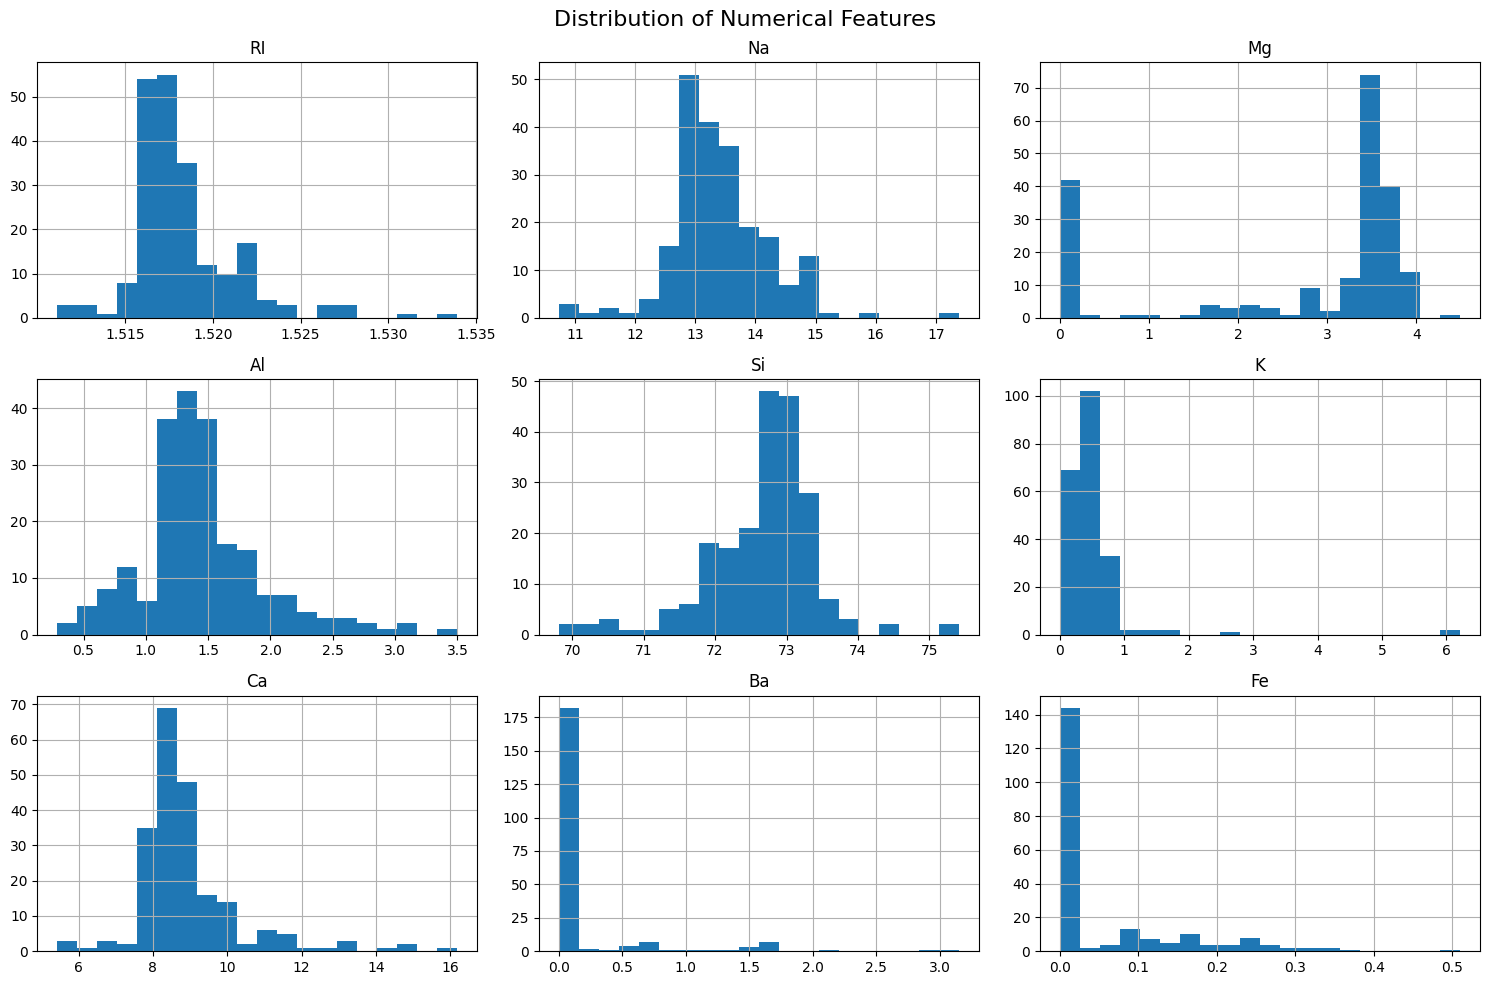

In [43]:
df[numerical_columns].hist(
  figsize =(15,10),
  bins = 20
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

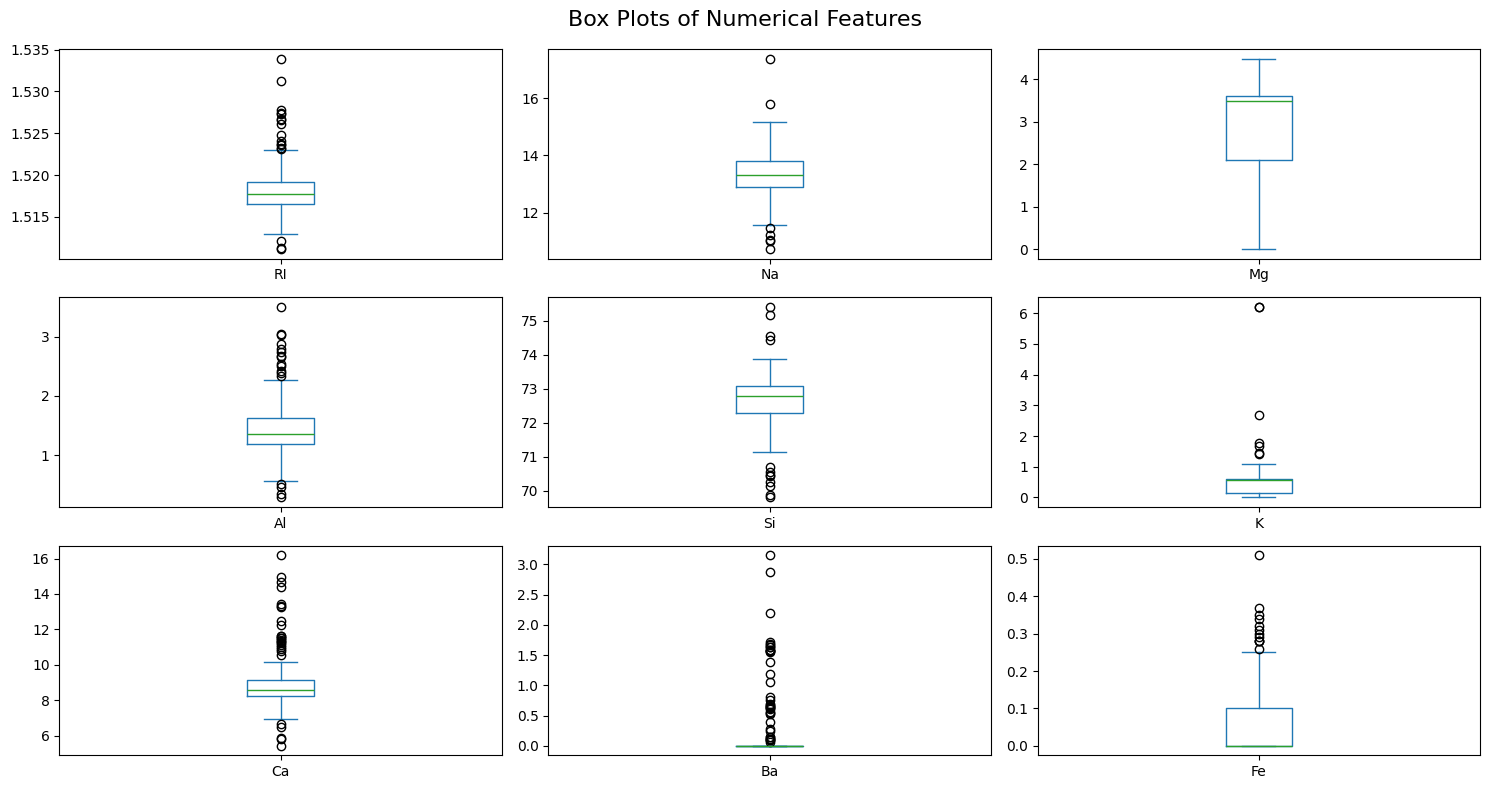

In [44]:
df[numerical_columns].plot(
    kind = 'box',
    subplots = True,
    layout=(3,3),
    figsize=(15,8)
)
plt.suptitle("Box Plots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

RI has few outliers.

Mg contains several extreme values.

Ba is highly right-skewed with many zero values.

Fe has many zero values and a few higher observations

In [45]:
co_relation = df.corr()

In [46]:
co_relation

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.198802,-0.127526,-0.400973,-0.539000,-0.287645,0.811183,0.001679,0.147083,-0.160140
Na,-0.198802,1.000000,-0.278420,0.167735,-0.064885,-0.264158,-0.278194,0.329080,-0.239374,0.508837
Mg,-0.127526,-0.278420,1.000000,-0.479575,-0.162437,0.007617,-0.446197,-0.491818,0.085426,-0.744195
Al,-0.400973,0.167735,-0.479575,1.000000,-0.016195,0.323683,-0.258068,0.480642,-0.080583,0.597432
Si,-0.539000,-0.064885,-0.162437,-0.016195,1.000000,-0.197281,-0.207145,-0.104389,-0.097717,0.147725
K,-0.287645,-0.264158,0.007617,0.323683,-0.197281,1.000000,-0.317032,-0.043653,-0.009372,-0.012455
Ca,0.811183,-0.278194,-0.446197,-0.258068,-0.207145,-0.317032,1.000000,-0.112208,0.126314,0.002677
Ba,0.001679,0.329080,-0.491818,0.480642,-0.104389,-0.043653,-0.112208,1.000000,-0.059729,0.574896
Fe,0.147083,-0.239374,0.085426,-0.080583,-0.097717,-0.009372,0.126314,-0.059729,1.000000,-0.191090
Type,-0.160140,0.508837,-0.744195,0.597432,0.147725,-0.012455,0.002677,0.574896,-0.191090,1.000000


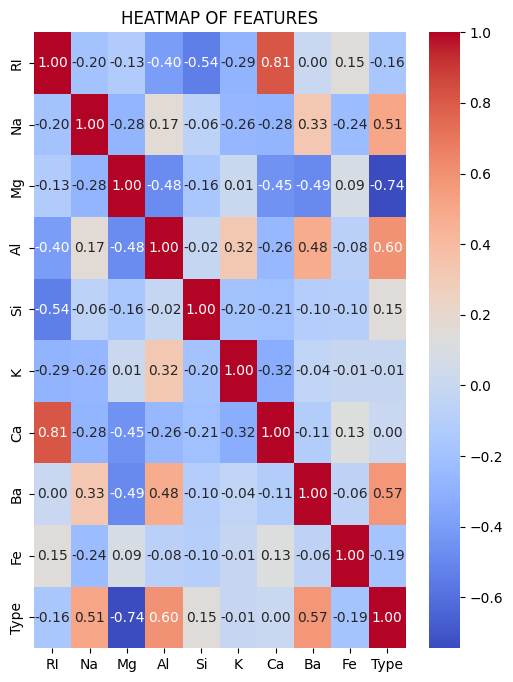

In [47]:
plt.figure(figsize=(6,8))

sns.heatmap(
    co_relation,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('HEATMAP OF FEATURES')
plt.show()

####Random Forest before Handling Class Imbalance (SMOTE)

scaling and using the scaled data for the training of the model

In [48]:
X = df.drop('Type',axis = 1)
y = df['Type']

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.879840,0.289558,1.257238,-0.706370,-1.133248,-0.673480,-0.143466,-0.353808,-0.588301
1,-0.243816,0.596403,0.639311,-0.180863,0.097037,-0.028962,-0.790201,-0.353808,-0.588301
2,-0.716412,0.154546,0.604596,0.182950,0.433746,-0.167073,-0.825349,-0.353808,-0.588301
3,-0.227291,-0.238216,0.701798,-0.322346,-0.058368,0.109149,-0.516041,-0.353808,-0.588301
4,-0.306608,-0.164573,0.653197,-0.423405,0.550299,0.078457,-0.621487,-0.353808,-0.588301


In [50]:
from sklearn.model_selection import train_test_split

In [51]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest is a tree-based algorithm that does not depend on feature magnitudes.

 Therefore, feature scaling is not required.

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
model = RandomForestClassifier(random_state= 42)

In [54]:
model

RandomForestClassifier(random_state=42)

In [55]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [56]:
y_pred = model.predict(X_test)

In [57]:
X_train.shape

(170, 9)

In [58]:
X_test.shape

(43, 9)

In [59]:
y_train.shape

(170,)

In [60]:
y_test.shape

(43,)

In [61]:
comparison =  pd.DataFrame({
    'Acutal': y_test.values,
    'predicted': y_pred
})

In [62]:
comparison.head(10)

,Acutal,predicted
0,1,1
1,7,7
2,1,1
3,7,7
4,2,2
5,2,2
6,1,1
7,2,2
8,2,2
9,2,1


In [63]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [64]:
from sklearn.metrics import accuracy_score
Accuracy_score = accuracy_score(y_test,y_pred)
print('Accurcay_score is : ',Accuracy_score)

Accurcay_score is :  0.7674418604651163


In [65]:
precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

0.7823920265780729

In [66]:
recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

0.7674418604651163

In [67]:
f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

0.7628818969448244

In [68]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.71      1.00      0.83        10
           2       0.67      0.67      0.67        15
           3       1.00      0.67      0.80         3
           5       0.50      0.33      0.40         3
           6       1.00      0.67      0.80         3
           7       1.00      0.89      0.94         9

    accuracy                           0.77        43
   macro avg       0.81      0.70      0.74        43
weighted avg       0.78      0.77      0.76        43



In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0  0  0  0]
 [ 4 10  0  1  0  0]
 [ 0  1  2  0  0  0]
 [ 0  2  0  1  0  0]
 [ 0  1  0  0  2  0]
 [ 0  1  0  0  0  8]]


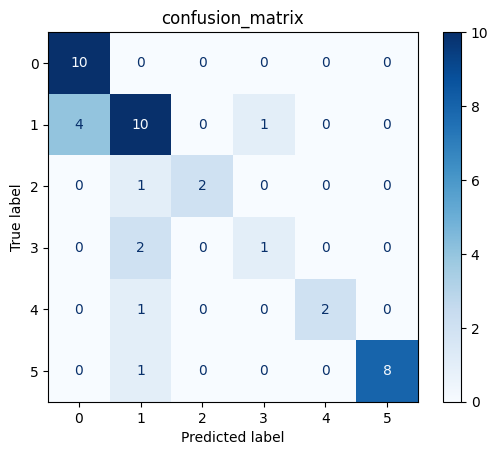

In [70]:
# visual representation of the confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix = cm).plot(cmap = 'Blues')

plt.title('confusion_matrix')
plt.show()

####Random Forest after Handling Class Imbalance (SMOTE)

In [71]:
df["Type"].value_counts()

,count
Type,
2,76
1,69
7,29
3,17
5,13
6,9


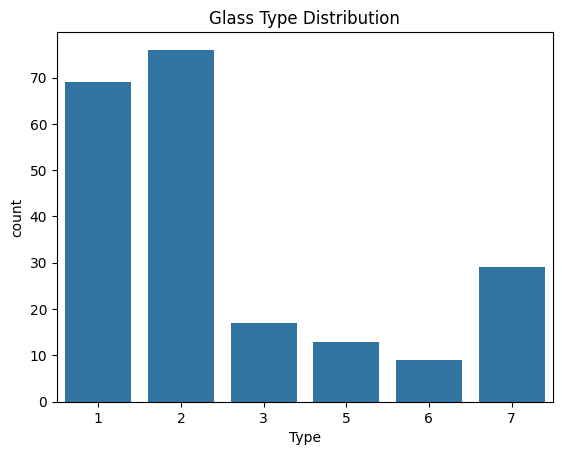

In [72]:
sns.countplot(x='Type', data=df)
plt.title("Glass Type Distribution")
plt.show()

The count plot shows that the Glass dataset has an uneven distribution of target classes. Types 1 and 2 have the highest number of observations, while Types 5 and 6 contain considerably fewer samples.

 This indicates a moderate class imbalance, which can affect model performance. Therefore, SMOTE is applied to balance the training data.

The Glass dataset contains an unequal number of observations across different classes. To reduce the effect of class imbalance,

 SMOTE (Synthetic Minority Oversampling Technique) is used.

  SMOTE creates synthetic samples for minority classes, resulting in a more balanced training dataset without simply duplicating existing observations.

In [73]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Type
2    61
1    59
7    20
3    14
5    10
6     6
Name: count, dtype: int64

After SMOTE
Type
2    61
3    61
1    61
7    61
5    61
6    61
Name: count, dtype: int64


In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.7209302325581395


In [76]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [77]:
precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

0.7531305903398927

In [78]:
recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

0.7209302325581395

In [79]:
f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

0.7266900187779864

In [80]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           1       0.54      0.70      0.61        10
           2       0.75      0.60      0.67        15
           3       0.50      0.67      0.57         3
           5       0.75      1.00      0.86         3
           6       1.00      1.00      1.00         3
           7       1.00      0.78      0.88         9

    accuracy                           0.72        43
   macro avg       0.76      0.79      0.76        43
weighted avg       0.75      0.72      0.73        43



In [81]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[7 1 2 0 0 0]
 [5 9 0 1 0 0]
 [1 0 2 0 0 0]
 [0 0 0 3 0 0]
 [0 0 0 0 3 0]
 [0 2 0 0 0 7]]


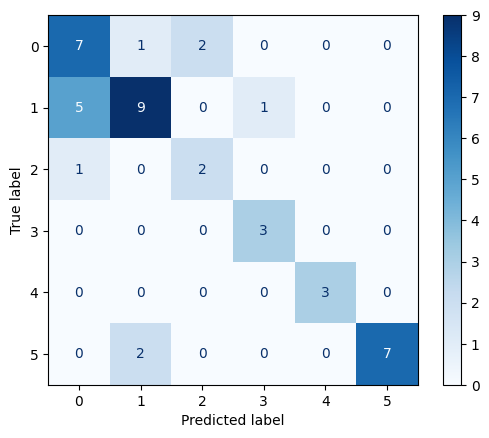

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap = 'Blues')

plt.show()

In [83]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Mg,0.184693
1,Na,0.156560
6,Ca,0.128371
5,K,0.118323
0,RI,0.112635
3,Al,0.105160
7,Ba,0.103719
4,Si,0.069702
8,Fe,0.020836


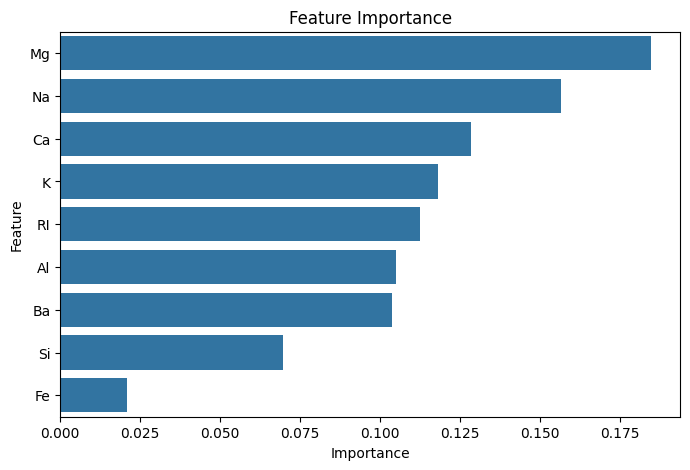

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

The feature importance plot indicates the relative contribution of each feature in predicting the glass type.

 Features with higher importance values have a greater influence on the model's decisions, while features with lower importance contribute less.

Bagging (Bootstrap Aggregating)

Bagging (Bootstrap Aggregating) is an ensemble learning technique that improves the performance and stability of machine learning models by combining the predictions of multiple base models.

 Different bootstrap samples are created from the original training dataset, and each sample is used to train a separate model independently.

 The final prediction is obtained by majority voting for classification problems or averaging for regression problems.

 Bagging mainly helps reduce variance and minimizes the risk of overfitting.

In [85]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(
    X_train_smote,
    y_train_smote
)

bag_pred = bagging.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score

bag_accuracy = accuracy_score(
    y_test,
    bag_pred
)

print("Bagging Accuracy :", bag_accuracy)

Bagging Accuracy : 0.7441860465116279


In [87]:
from sklearn.metrics import precision_score

bag_precision = precision_score(
    y_test,
    bag_pred,
    average="weighted"
)

print("Bagging Precision :", bag_precision)

Bagging Precision : 0.7857444880700695


In [88]:
from sklearn.metrics import recall_score

bag_recall = recall_score(
    y_test,
    bag_pred,
    average="weighted"
)

print("Bagging Recall :", bag_recall)

Bagging Recall : 0.7441860465116279


In [89]:
from sklearn.metrics import f1_score

bag_f1 = f1_score(
    y_test,
    bag_pred,
    average="weighted"
)

print("Bagging F1 Score :", bag_f1)

Bagging F1 Score : 0.7482856290995826


In [99]:

print(classification_report(
    y_test,
    bag_pred
))

              precision    recall  f1-score   support

           1       0.57      0.80      0.67        10
           2       0.82      0.60      0.69        15
           3       0.67      0.67      0.67         3
           5       0.60      1.00      0.75         3
           6       1.00      1.00      1.00         3
           7       1.00      0.78      0.88         9

    accuracy                           0.74        43
   macro avg       0.78      0.81      0.78        43
weighted avg       0.79      0.74      0.75        43



Boosting

Boosting is an ensemble learning technique in which multiple weak learners are trained sequentially.

 Each new model focuses on correcting the errors made by the previous model.

 The final prediction is obtained by combining the predictions of all the models.

 Boosting mainly reduces bias and usually provides higher predictive performance, although it may be more sensitive to noisy data and outliers.

In [91]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boost.fit(
    X_train_smote,
    y_train_smote
)

boost_pred = boost.predict(X_test)

In [92]:
boost_accuracy = accuracy_score(
    y_test,
    boost_pred
)

print("AdaBoost Accuracy :", boost_accuracy)

AdaBoost Accuracy : 0.6046511627906976


In [93]:
boost_precision = precision_score(
    y_test,
    boost_pred,
    average="weighted"
)

print("AdaBoost Precision :", boost_precision)

AdaBoost Precision : 0.6987004103967168


In [94]:
boost_recall = recall_score(
    y_test,
    boost_pred,
    average="weighted"
)

print("AdaBoost Recall :", boost_recall)

AdaBoost Recall : 0.6046511627906976


In [95]:
boost_f1 = f1_score(
    y_test,
    boost_pred,
    average="weighted"
)

print("AdaBoost F1 Score :", boost_f1)

AdaBoost F1 Score : 0.601218161683278


In [96]:
print("Accuracy :",accuracy_score(y_test,boost_pred))

print(classification_report(
    y_test,
    boost_pred
))

Accuracy : 0.6046511627906976
              precision    recall  f1-score   support

           1       0.53      0.90      0.67        10
           2       0.70      0.47      0.56        15
           3       0.25      0.33      0.29         3
           5       1.00      0.33      0.50         3
           6       0.50      1.00      0.67         3
           7       1.00      0.56      0.71         9

    accuracy                           0.60        43
   macro avg       0.66      0.60      0.57        43
weighted avg       0.70      0.60      0.60        43



In [97]:
comparison = pd.DataFrame({
    "Model":[
        "Random Forest",
        "Bagging",
        "AdaBoost"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,bag_pred),
        accuracy_score(y_test,boost_pred)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.720930
1,Bagging,0.744186
2,AdaBoost,0.604651


In [98]:
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Bagging",
        "AdaBoost"
    ],

    "Accuracy": [
        accuracy,
        bag_accuracy,
        boost_accuracy
    ],

    "Precision": [
        precision,
        bag_precision,
        boost_precision
    ],

    "Recall": [
        recall,
        bag_recall,
        boost_recall
    ],

    "F1 Score": [
        f1,
        bag_f1,
        boost_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.720930,0.753131,0.720930,0.726690
1,Bagging,0.744186,0.785744,0.744186,0.748286
2,AdaBoost,0.604651,0.698700,0.604651,0.601218


| Bagging                                               | Boosting                                                                                  |
| ----------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| Models are trained independently.                     | Models are trained sequentially.                                                          |
| Uses bootstrap sampling to create different datasets. | Uses the same dataset while giving higher importance to previously misclassified samples. |
| Reduces variance.                                     | Reduces bias.                                                                             |
| Less prone to overfitting.                            | Can overfit if too many estimators are used.                                              |
| Faster because models are trained in parallel.        | Slower because each model depends on the previous one.                                    |
| Example: Random Forest                                | Example: AdaBoost, Gradient Boosting, XGBoost                                             |


####conclusion

The Glass dataset was successfully analyzed using the Random Forest algorithm. Exploratory Data Analysis (EDA) was performed to understand the dataset, identify missing values, detect duplicate records, and visualize feature distributions and relationships. Since the dataset contained only numerical features, no encoding techniques were required. Feature scaling was performed using StandardScaler, and class imbalance was handled using the SMOTE technique.

Random Forest, Bagging, and AdaBoost classifiers were implemented and evaluated using Accuracy, Precision, Recall, and F1-Score. Feature importance analysis identified the most influential variables affecting glass type classification. Based on the comparison of evaluation metrics, the best-performing model can be selected for predicting the glass type efficiently.